In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error

In [2]:
#  LOAD DATA

df = pd.read_csv("/content/student_cleaned_dataset.csv")

In [3]:
# CLEANING
df.fillna(0, inplace=True)
df = df.astype(float)

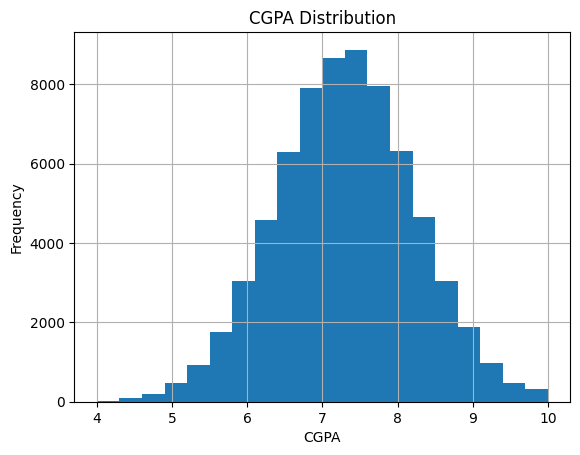

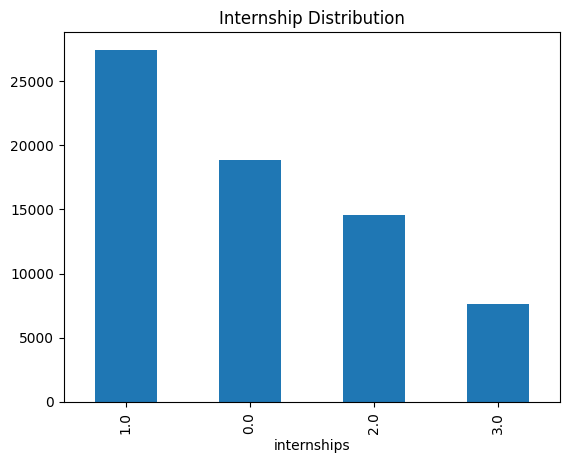

In [4]:
# EDA VISUALIZATION
plt.figure()
df['cgpa'].hist(bins=20)
plt.title("CGPA Distribution")
plt.xlabel("CGPA")
plt.ylabel("Frequency")
plt.show()

plt.figure()
df['internships'].value_counts().plot(kind='bar')
plt.title("Internship Distribution")
plt.show()

In [5]:
# FEATURE ENGINEERING

df['profile_score'] = (
    df['cgpa'] * 0.4 +
    df['internships'] * 0.2 +
    df['projects_count'] * 0.2 +
    df['certifications'] * 0.2
)

df['effort_score'] = (
    df['internships'] +
    df['projects_count'] +
    df['certifications']
)

df['employability_index'] = df['profile_score'] * df['industry_demand']

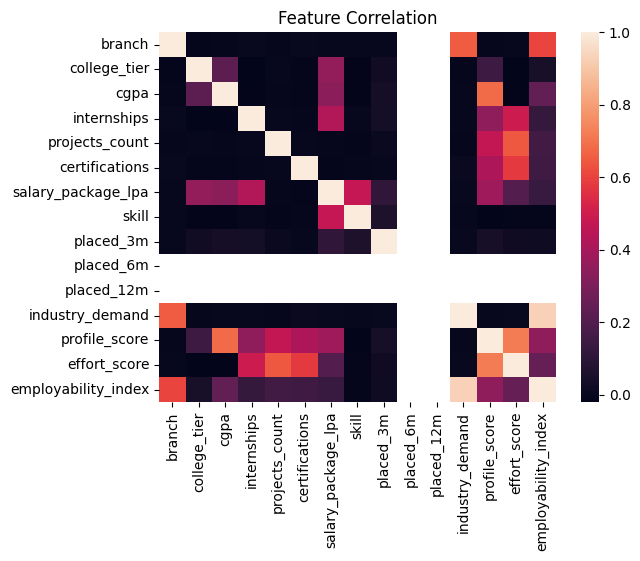

In [6]:
# Correlation Heatmap
plt.figure()
sns.heatmap(df.corr(), annot=False)
plt.title("Feature Correlation")
plt.show()

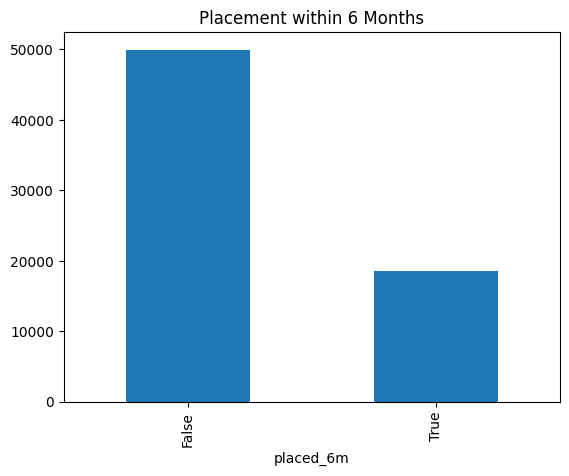

In [7]:
#  CREATE TARGET LABELS

df['placed_3m'] = (
    (df['cgpa'] * 0.5 +
     df['internships'] * 1.0 +
     df['skill'] * 0.5) >
    (df['cgpa'] * 0.5 +
     df['internships'] * 1.0 +
     df['skill'] * 0.5).quantile(0.8)
).astype(int)

df['placed_3m'] = df['placed_3m'] & (np.random.rand(len(df)) > 0.12)

df['placed_6m'] = (
    (df['cgpa'] * 0.3 +
     df['internships'] * 0.2 +
     df['projects_count'] * 0.2 +
     df['skill'] * 0.3) >
    (df['cgpa'] * 0.3 +
     df['internships'] * 0.2 +
     df['projects_count'] * 0.2 +
     df['skill'] * 0.3).quantile(0.7)
).astype(int)

df['placed_6m'] = df['placed_6m'] & (np.random.rand(len(df)) > 0.1)

df['placed_12m'] = (
    (df['cgpa'] * 0.2 +
     df['internships'] * 0.2 +
     df['projects_count'] * 0.2 +
     df['certifications'] * 0.2 +
     df['skill'] * 0.2) >
    (df['cgpa'] * 0.2 +
     df['internships'] * 0.2 +
     df['projects_count'] * 0.2 +
     df['certifications'] * 0.2 +
     df['skill'] * 0.2).quantile(0.4)
).astype(int)

df['placed_12m'] = df['placed_12m'] | (np.random.rand(len(df)) > 0.9)

plt.figure()
df['placed_6m'].value_counts().plot(kind='bar')
plt.title("Placement within 6 Months")
plt.show()


In [8]:
print(df['placed_3m'].value_counts())
print(df['placed_6m'].value_counts())
print(df['placed_12m'].value_counts())

placed_3m
False    56460
True     12015
Name: count, dtype: int64
placed_6m
False    49955
True     18520
Name: count, dtype: int64
placed_12m
True     43821
False    24654
Name: count, dtype: int64


In [9]:
# FEATURES & TARGETS

features = [
    'branch','college_tier','cgpa','internships',
    'projects_count','certifications','skill',
    'industry_demand','profile_score','effort_score','employability_index'
]

X = df[features]

y3 = df['placed_3m']
y6 = df['placed_6m']
y12 = df['placed_12m']
y_salary = df['salary_package_lpa']

X_train, X_test, y3_train, y3_test = train_test_split(X, y3, test_size=0.2, random_state=42)
X_train, X_test, y6_train, y6_test = train_test_split(X, y6, test_size=0.2, random_state=42)
X_train, X_test, y12_train, y12_test = train_test_split(X, y12, test_size=0.2, random_state=42)
X_train, X_test, ys_train, ys_test = train_test_split(X, y_salary, test_size=0.2, random_state=42)

In [10]:
# MODEL TRAINING

model_3m = RandomForestClassifier(n_estimators=100)
model_6m = RandomForestClassifier(n_estimators=100)
model_12m = RandomForestClassifier(n_estimators=100)

model_3m.fit(X_train, y3_train)
model_6m.fit(X_train, y6_train)
model_12m.fit(X_train, y12_train)

salary_model = RandomForestRegressor(n_estimators=100)
salary_model.fit(X_train, ys_train)

RandomForestRegressor()

In [11]:
# EVALUATION

print("3M Accuracy:", accuracy_score(y3_test, model_3m.predict(X_test)))
print("6M Accuracy:", accuracy_score(y6_test, model_6m.predict(X_test)))
print("12M Accuracy:", accuracy_score(y12_test, model_12m.predict(X_test)))

pred_salary = salary_model.predict(X_test)
print("Salary MAE:", mean_absolute_error(ys_test, pred_salary))

3M Accuracy: 0.9700620664476086
6M Accuracy: 0.9609346476816356
12M Accuracy: 0.9508579773640015
Salary MAE: 1.372187772924309


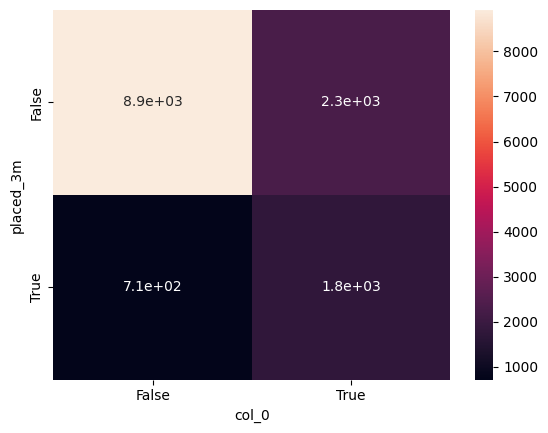

In [12]:
#Confusion Matrix
cm=pd.crosstab(y3_test, model_6m.predict(X_test))
sns.heatmap(cm, annot=True)
plt.show()

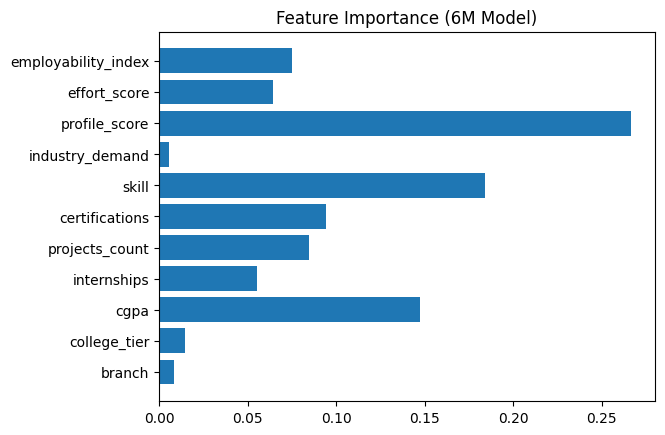

In [13]:
# FEATURE IMPORTANCE

importances = model_6m.feature_importances_

plt.figure()
plt.barh(features, importances)
plt.title("Feature Importance (6M Model)")
plt.show()

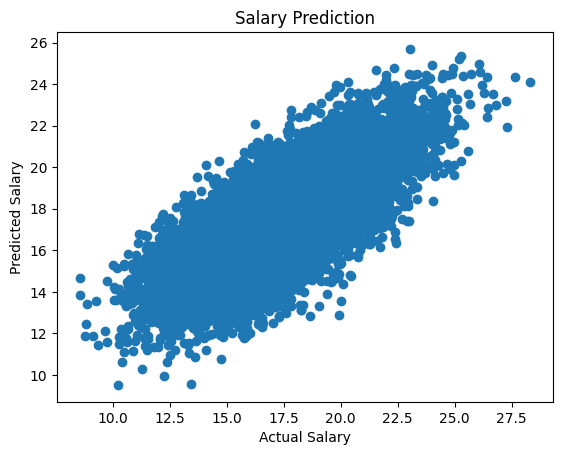

In [14]:
# SALARY PLOT

plt.figure()
plt.scatter(ys_test, pred_salary)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Salary Prediction")
plt.show()

In [15]:
# RISK CALCULATION

def risk_score(p3, p6, salary):
    risk = (1 - p6) * 0.5 + (1 - p3) * 0.3
    if salary < 5:
        risk += 0.2

    if risk > 0.7:
        return "High", risk
    elif risk > 0.4:
        return "Medium", risk
    else:
        return "Low", risk

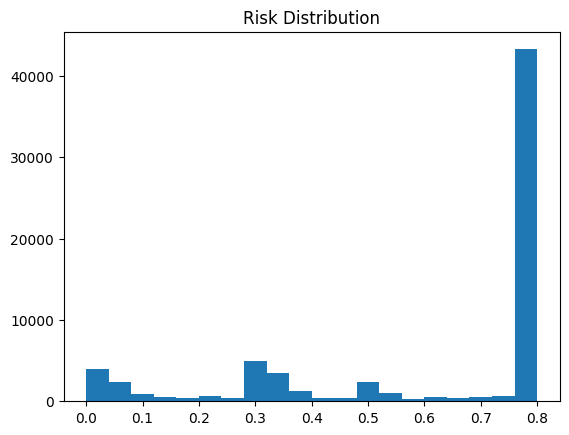

In [16]:
# Risk distribution

df['p3'] = model_3m.predict_proba(X)[:,1]
df['p6'] = model_6m.predict_proba(X)[:,1]

df['risk_numeric'] = (1 - df['p6']) * 0.5 + (1 - df['p3']) * 0.3

plt.figure()
plt.hist(df['risk_numeric'], bins=20)
plt.title("Risk Distribution")
plt.show()


In [17]:


def explain(student):
    reasons = []
    if student['cgpa'] < 7:
        reasons.append("Low CGPA")
    if student['internships'] < 1:
        reasons.append("No internships")
    if student['certifications'] < 2:
        reasons.append("Few certifications")
    if student['industry_demand'] < 3:
        reasons.append("Low demand field")
    return reasons


def recommend(student):
    actions = []
    if student['internships'] < 2:
        actions.append("Do internships")
    if student['projects_count'] < 3:
        actions.append("Build projects")
    if student['certifications'] < 3:
        actions.append("Add certifications")
    if student['skill'] < 6:
        actions.append("Improve skills")
    return actions

In [18]:
# Prediction Function
def predict(student):
    df_s = pd.DataFrame([student])

    # Feature Engineering
    df_s['profile_score'] = (
        df_s['cgpa'] * 0.4 +
        df_s['internships'] * 0.2 +
        df_s['projects_count'] * 0.2 +
        df_s['certifications'] * 0.2
    )

    df_s['effort_score'] = (
        df_s['internships'] +
        df_s['projects_count'] +
        df_s['certifications']
    )

    df_s['employability_index'] = df_s['profile_score'] * df_s['industry_demand']

    df_s = df_s[features]

    # Predictions
    p3 = model_3m.predict_proba(df_s)[0][1]
    p6 = model_6m.predict_proba(df_s)[0][1]
    p12 = model_12m.predict_proba(df_s)[0][1]
    salary = salary_model.predict(df_s)[0]

    risk, score = risk_score(p3, p6, salary)

    # Better Explanation
    reasons = explain(student)

    # 🔥 Smart Recommendations
    actions = []

    if student['skill'] < 6:
        actions.append("Improve coding skills (DSA / Python)")

    if student['internships'] < 2:
        actions.append("Gain practical experience through internships")

    if student['projects_count'] < 3:
        actions.append("Build 2–3 strong real-world projects")

    if student['certifications'] < 3:
        actions.append("Complete relevant certifications (Coursera/Udemy)")

    if student['cgpa'] < 7:
        actions.append("Improve academic performance or highlight strengths")

    # General actions (always useful)
    actions.extend([
        "Apply to at least 15 companies per week",
        "Update resume with measurable achievements",
        "Practice mock interviews regularly"
    ])

    # Clean Output Format
    # print("\n===== AI PLACEMENT RISK REPORT =====\n")

    print("Placement Probability:")
    print(f"   • Within 3 Months : {round(p3*100,1)}%")
    print(f"   • Within 6 Months : {round(p6*100,1)}%")
    print(f"   • Within 12 Months: {round(p12*100,1)}%")

    print("\nExpected Salary:")
    print(f"   ₹ {round(salary,2)} LPA")

    print("\nLoan repayment risk Level:")
    print(f"   {risk} (Score: {round(score,2)})")

    print("\nKey Risk Factors:")
    if reasons:
        for r in reasons:
            print(f"   - {r}")
    else:
        print("   - No major risk factors detected")

    print("\nRecommended Next Steps:")
    for act in actions:
        print(f"   {act}")


In [19]:
#  TEST SAMPLE


student = {
    'branch': 2,
    'college_tier': 2,
    'cgpa': 8.69,
    'internships': 2,
    'projects_count': 3,
    'certifications': 4,
    'skill': 5,
    'industry_demand': 3
}

print("\nFinal Prediction:")
print(predict(student))


Final Prediction:
Placement Probability:
   • Within 3 Months : 98.0%
   • Within 6 Months : 96.0%
   • Within 12 Months: 100.0%

Expected Salary:
   ₹ 20.62 LPA

Loan repayment risk Level:
   Low (Score: 0.03)

Key Risk Factors:
   - No major risk factors detected

Recommended Next Steps:
   Improve coding skills (DSA / Python)
   Apply to at least 15 companies per week
   Update resume with measurable achievements
   Practice mock interviews regularly
None


In [23]:
import joblib

# Save models
joblib.dump(model_3m, "model_3m.pkl", compress=3)
joblib.dump(model_6m, "model_6m.pkl", compress=3)
joblib.dump(model_12m, "model_12m.pkl", compress=3)
joblib.dump(salary_model, "salary_model.pkl", compress=9)

# Save feature list (VERY IMPORTANT)
joblib.dump(features, "features.pkl")

print("✅ Models saved successfully!")

✅ Models saved successfully!
